<a href="https://colab.research.google.com/github/Onndwelam/Analystlab-africa-week2datascience/blob/main/Week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HealthConnect Week 5: No-Show Prediction

## Introduction

Healthcare appointment no-shows can reduce clinic efficiency, waste appointment capacity, and delay patient care. By identifying appointments that are more likely to result in a no-show, HealthConnect can support earlier interventions such as reminders, follow-up communication, and improved scheduling decisions.

This Week 5 Data Science project builds directly on the Week 4 problem definition. The objective is to develop an initial, interpretable machine-learning model that predicts whether an appointment will be attended or missed.

The target variable is defined as:

- `0` = Attended
- `1` = No-Show

Cancelled appointments are excluded from the primary model because cancellation is operationally different from failing to attend.

The project uses the official HealthConnect appointment dataset and applies data cleaning, feature engineering, preprocessing, and baseline modelling techniques. A chronological 80/20 train/test split is used to provide a realistic estimate of how the model may perform on future appointments.

Logistic Regression is used as the main baseline model because it is suitable for binary classification and provides interpretable results. A Dummy Classifier is also used as a benchmark to determine whether Logistic Regression performs better than a basic prediction strategy.

The analysis addresses missing values, duplicate records, invalid numeric values, categorical variables, and potential data leakage. Variables such as `waiting_time_minutes` and `appointment_outcome` are excluded because they may only be known after the appointment and could provide information that would not be available when making a prediction.

This notebook documents the Week 4 review, data preparation, exploratory analysis, feature engineering, train/test strategy, baseline model development, evaluation results, limitations, risks, and recommendations for Week 6.

1. Import libraries and create folders

In [12]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Project folders
BASE_DIR = Path("/content")

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = BASE_DIR / "figures"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR = BASE_DIR / "reports"

for folder in [
    DATA_DIR,
    PROCESSED_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    REPORTS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

print("Folders created successfully.")


Folders created successfully.


2. Load the HealthConnect dataset

In [13]:
# Correct file path in Google Colab
DATA_PATH = Path("/content/HealthConnect_Appointment_Data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())


Dataset loaded successfully.
Rows: 5000
Columns: 18


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


3. Inspect the dataset


In [14]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

display(
    missing_report.sort_values(
        "missing_count",
        ascending=False
    )
)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset summary:")
display(df.describe(include="all").T)


Column names:
['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome']

Data types:


,0
appointment_id,object
patient_id,object
gender,object
age,int64
age_group,object
appointment_type,object
booking_date,object
appointment_date,object
appointment_day,object
appointment_time,object



Missing values:


,missing_count,missing_percentage
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20
appointment_id,0,0.00
patient_id,0,0.00
gender,0,0.00
booking_date,0,0.00
age,0,0.00
age_group,0,0.00
appointment_type,0,0.00



Duplicate rows: 0

Dataset summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appointment_id,5000,5000,HC-05000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,5000,1696,P-1742,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,5000,3,Female,2488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,48.7948,18.138547,18.0,33.0,49.0,64.0,80.0
age_group,5000,6,65+,1241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_type,5000,4,General Consultation,2086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,5000,593,8/24/2025,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_date,5000,545,3/14/2026,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_day,5000,7,Wednesday,737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_time,5000,3,Morning,2227,NaN,NaN,NaN,NaN,NaN,NaN,NaN


4. Clean column names and text values


In [15]:
# Standardise column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

# Clean text columns
text_columns = df.select_dtypes(
    include=["object"]
).columns

for column in text_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
    )

# Convert common missing-value text to NaN
missing_text = [
    "",
    " ",
    "na",
    "n/a",
    "nan",
    "none",
    "null",
    "unknown"
]

for column in text_columns:
    df[column] = df[column].replace(
        missing_text,
        np.nan
    )

print("Cleaned columns:")
print(df.columns.tolist())


Cleaned columns:
['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome']


5. Convert data types


In [16]:
# Date columns
date_columns = [
    "appointment_date",
    "booking_date"
]

for column in date_columns:
    if column in df.columns:
        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )

# Numeric columns
numeric_columns = [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes"
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

display(df.dtypes)


,0
appointment_id,string[python]
patient_id,string[python]
gender,string[python]
age,int64
age_group,string[python]
appointment_type,string[python]
booking_date,datetime64[ns]
appointment_date,datetime64[ns]
appointment_day,string[python]
appointment_time,string[python]


In [17]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

duplicates_after = df.duplicated().sum()

print("Duplicates before removal:", duplicates_before)
print("Duplicates after removal:", duplicates_after)
print("New dataset shape:", df.shape)


Duplicates before removal: 0
Duplicates after removal: 0
New dataset shape: (5000, 18)


7. Validate numeric values


In [18]:
# Replace invalid negative values with missing values
non_negative_columns = [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes"
]

for column in non_negative_columns:
    if column in df.columns:
        df.loc[df[column] < 0, column] = np.nan

# Check age range
if "age" in df.columns:
    df.loc[
        (df["age"] > 120),
        "age"
    ] = np.nan

# Check previous no-shows cannot exceed previous appointments
if {
    "previous_appointments",
    "previous_no_shows"
}.issubset(df.columns):

    invalid_history = (
        df["previous_no_shows"] >
        df["previous_appointments"]
    )

    print(
        "Invalid previous history records:",
        invalid_history.sum()
    )

    df.loc[
        invalid_history,
        "previous_no_shows"
    ] = np.nan


Invalid previous history records: 0


8. Explore appointment outcomes


appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: Int64


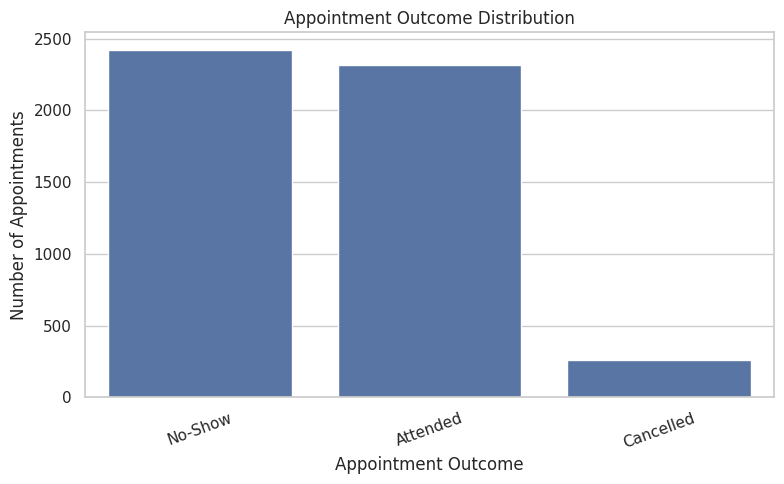

In [19]:
print(
    df["appointment_outcome"]
    .value_counts(dropna=False)
)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="appointment_outcome",
    order=df["appointment_outcome"].value_counts().index
)

plt.title("Appointment Outcome Distribution")
plt.xlabel("Appointment Outcome")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "appointment_outcome_distribution.png",
    dpi=300
)

plt.show()


9. Exclude cancellations and create the target
The primary model predicts:

0 = Attended
1 = No-Show
Cancellations are excluded because they represent a different operational outcome.

In [20]:
print("Original outcomes:")
print(df["appointment_outcome"].value_counts())

# Keep only attended and no-show appointments
model_df = df[
    df["appointment_outcome"].isin([
        "Attended",
        "No-Show"
    ])
].copy()

# Create binary target
model_df["target_no_show"] = (
    model_df["appointment_outcome"]
    .str.lower()
    .eq("no-show")
    .astype(int)
)

print("\nRows used for modelling:", len(model_df))

print("\nTarget distribution:")
print(model_df["target_no_show"].value_counts())

print("\nTarget percentage:")
print(
    model_df["target_no_show"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


Original outcomes:
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: Int64

Rows used for modelling: 4737

Target distribution:
target_no_show
1    2423
0    2314
Name: count, dtype: int64

Target percentage:
target_no_show
1    51.15
0    48.85
Name: proportion, dtype: float64


10. Feature engineering


In [21]:
# Sort records by appointment date
if "appointment_date" in model_df.columns:
    model_df = model_df.sort_values(
        "appointment_date"
    ).reset_index(drop=True)

# Previous no-show rate
if {
    "previous_appointments",
    "previous_no_shows"
}.issubset(model_df.columns):

    model_df["previous_no_show_rate"] = np.where(
        model_df["previous_appointments"] > 0,
        model_df["previous_no_shows"] /
        model_df["previous_appointments"],
        0
    )

# Previous appointment history indicator
if "previous_appointments" in model_df.columns:
    model_df["has_previous_history"] = (
        model_df["previous_appointments"] > 0
    ).astype(int)

# Previous no-show indicator
if "previous_no_shows" in model_df.columns:
    model_df["has_previous_no_show"] = (
        model_df["previous_no_shows"] > 0
    ).astype(int)

# Reminder indicator
if "reminder_sent" in model_df.columns:
    model_df["reminder_received"] = (
        model_df["reminder_sent"]
        .astype("string")
        .str.lower()
        .map({
            "yes": 1,
            "no": 0
        })
    )

# Date-based features
if "appointment_date" in model_df.columns:

    model_df["appointment_year"] = (
        model_df["appointment_date"].dt.year
    )

    model_df["appointment_month"] = (
        model_df["appointment_date"].dt.month
    )

    model_df["appointment_weekday"] = (
        model_df["appointment_date"].dt.weekday
    )

    model_df["is_weekend"] = (
        model_df["appointment_date"].dt.weekday >= 5
    ).astype(int)

# Lead-time bands
if "booking_lead_days" in model_df.columns:

    model_df["lead_time_band"] = pd.cut(
        model_df["booking_lead_days"],
        bins=[
            -np.inf,
            7,
            30,
            90,
            np.inf
        ],
        labels=[
            "0_to_7_days",
            "8_to_30_days",
            "31_to_90_days",
            "over_90_days"
        ]
    )

# Distance bands
if "distance_to_clinic_km" in model_df.columns:

    model_df["distance_band"] = pd.cut(
        model_df["distance_to_clinic_km"],
        bins=[
            -np.inf,
            5,
            15,
            30,
            np.inf
        ],
        labels=[
            "near",
            "moderate",
            "far",
            "very_far"
        ]
    )

display(model_df.head())


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,target_no_show,previous_no_show_rate,has_previous_history,has_previous_no_show,reminder_received,appointment_year,appointment_month,appointment_weekday,is_weekend,lead_time_band,distance_band
0,HC-04691,P-0787,Male,63.0,55-64,Follow-up,2025-01-01,2025-01-01,Wednesday,Afternoon,0.0,4.0,1.0,Yes,SMS,0.7,54.0,Attended,0,0.25,1,1,1,2025,1,2,0,0_to_7_days,near
1,HC-01482,P-0695,Male,63.0,55-64,Follow-up,2024-11-08,2025-01-01,Wednesday,Morning,54.0,3.0,0.0,No,<NA>,7.1,40.0,No-Show,1,0.00,1,0,0,2025,1,2,0,31_to_90_days,moderate
2,HC-01949,P-1652,Male,29.0,25-34,General Consultation,2024-12-10,2025-01-01,Wednesday,Afternoon,22.0,3.0,0.0,Yes,SMS,6.0,29.0,Attended,0,0.00,1,0,1,2025,1,2,0,8_to_30_days,moderate
3,HC-03674,P-1027,Male,21.0,18-24,Diagnostic Test,2024-12-31,2025-01-01,Wednesday,Morning,1.0,3.0,0.0,Yes,SMS,9.9,40.0,No-Show,1,0.00,1,0,1,2025,1,2,0,0_to_7_days,moderate
4,HC-02259,P-1425,Male,20.0,18-24,General Consultation,2024-12-24,2025-01-01,Wednesday,Morning,8.0,2.0,0.0,Yes,Email,1.4,21.0,Attended,0,0.00,1,0,1,2025,1,2,0,8_to_30_days,near


11. Explore no-show rates


In [22]:
def plot_no_show_rate(
    data,
    feature,
    title,
    filename
):
    if feature not in data.columns:
        print(f"{feature} not available.")
        return

    summary = (
        data.groupby(
            feature,
            observed=False
        )["target_no_show"]
        .mean()
        .mul(100)
        .reset_index()
        .sort_values(
            "target_no_show",
            ascending=False
        )
    )

    plt.figure(figsize=(9, 5))

    sns.barplot(
        data=summary,
        x=feature,
        y="target_no_show",
        color="steelblue"
    )

    plt.title(title)
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("No-Show Rate (%)")
    plt.xticks(rotation=30)
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / filename,
        dpi=300
    )

    plt.show()

    display(summary)


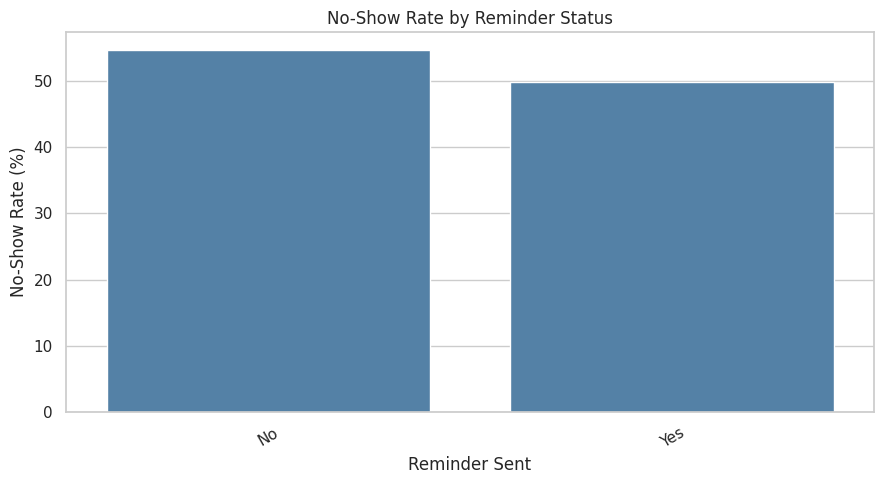

,reminder_sent,target_no_show
0,No,54.630350
1,Yes,49.855156


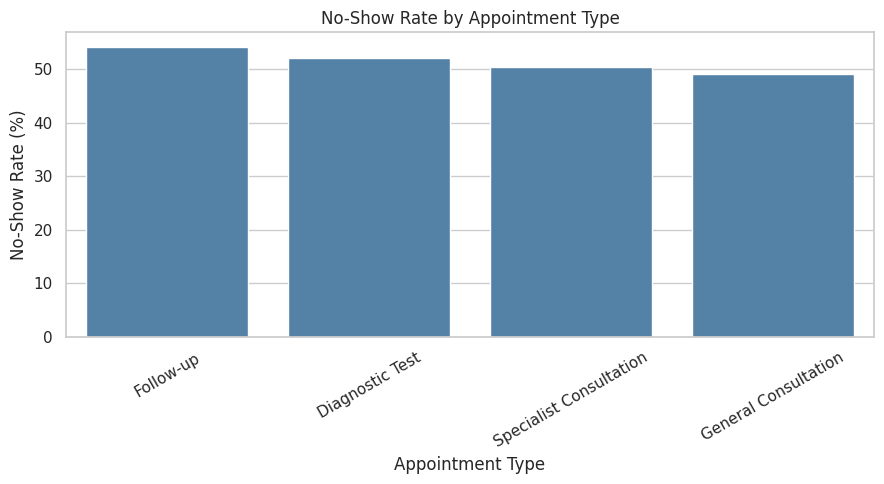

,appointment_type,target_no_show
1,Follow-up,54.166667
0,Diagnostic Test,52.028219
3,Specialist Consultation,50.472813
2,General Consultation,49.141414


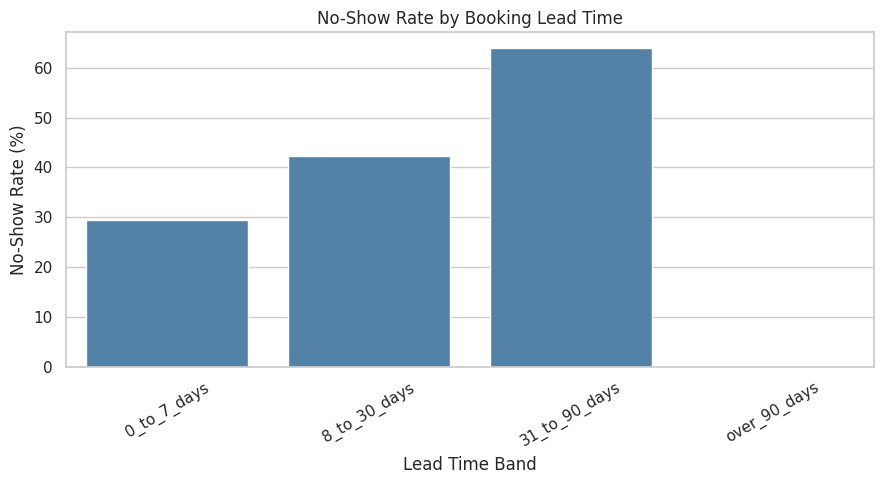

,lead_time_band,target_no_show
2,31_to_90_days,63.949433
1,8_to_30_days,42.305601
0,0_to_7_days,29.470199
3,over_90_days,NaN


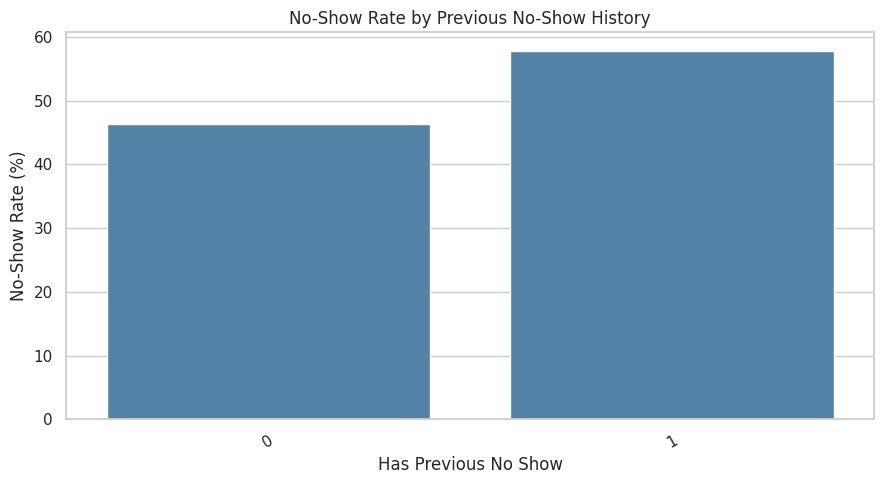

,has_previous_no_show,target_no_show
1,1,57.831325
0,0,46.302368


In [23]:
plot_no_show_rate(
    model_df,
    "reminder_sent",
    "No-Show Rate by Reminder Status",
    "no_show_rate_reminder.png"
)

plot_no_show_rate(
    model_df,
    "appointment_type",
    "No-Show Rate by Appointment Type",
    "no_show_rate_appointment_type.png"
)

plot_no_show_rate(
    model_df,
    "lead_time_band",
    "No-Show Rate by Booking Lead Time",
    "no_show_rate_lead_time.png"
)

plot_no_show_rate(
    model_df,
    "has_previous_no_show",
    "No-Show Rate by Previous No-Show History",
    "no_show_rate_previous_no_show.png"
)


12. Check numeric distributions


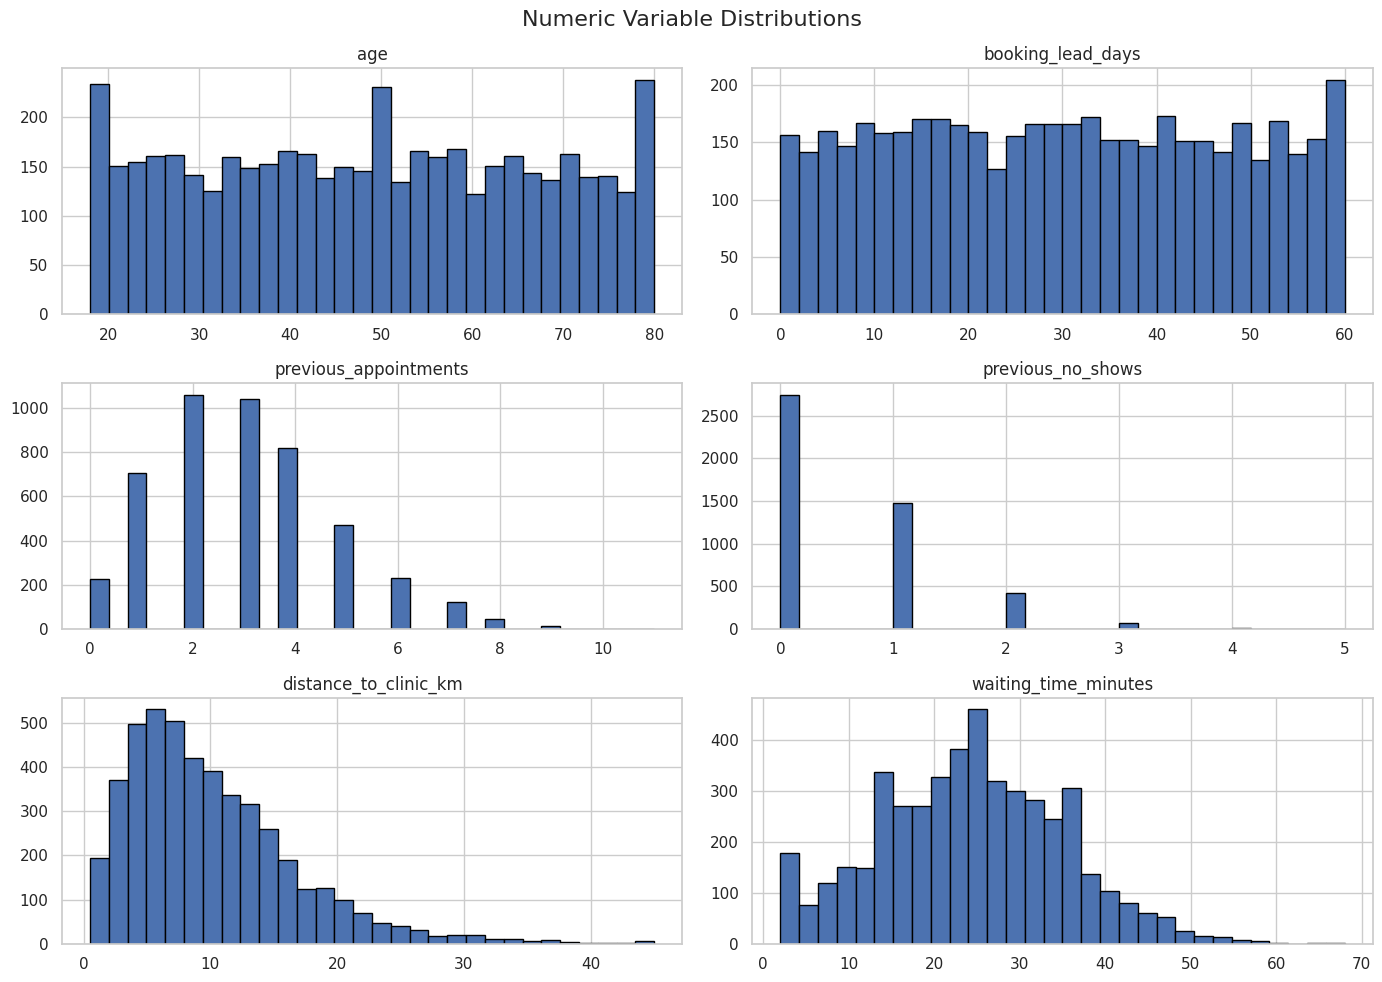

In [24]:
numeric_plot_columns = [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes"
]

available_numeric_columns = [
    column
    for column in numeric_plot_columns
    if column in model_df.columns
]

model_df[available_numeric_columns].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Numeric Variable Distributions",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "numeric_distributions.png",
    dpi=300
)

plt.show()


13. Correlation heatmap

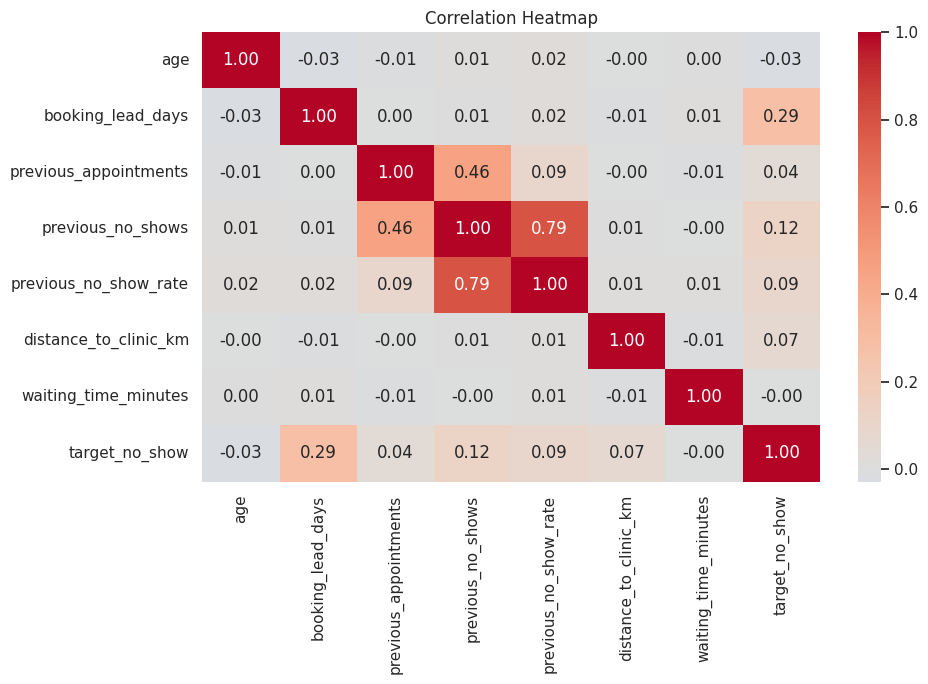

In [25]:
correlation_columns = [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "previous_no_show_rate",
    "distance_to_clinic_km",
    "waiting_time_minutes",
    "target_no_show"
]

available_correlation_columns = [
    column
    for column in correlation_columns
    if column in model_df.columns
]

correlation_matrix = model_df[
    available_correlation_columns
].corr(numeric_only=True)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation_heatmap.png",
    dpi=300
)

plt.show()


14. Save the processed dataset


In [26]:
processed_path = (
    PROCESSED_DIR /
    "healthconnect_processed_dataset.csv"
)

model_df.to_csv(
    processed_path,
    index=False
)

print("Processed dataset saved to:")
print(processed_path)


Processed dataset saved to:
/content/data/processed/healthconnect_processed_dataset.csv


15. Select modelling features
The following are excluded:

Patient and appointment IDs.
Original outcome.
Raw dates.
waiting_time_minutes, because it may only be known after the appointment and could cause leakage.

In [27]:
target = "target_no_show"

excluded_columns = [
    "target_no_show",
    "appointment_outcome",
    "appointment_id",
    "patient_id",
    "appointment_date",
    "booking_date",
    "waiting_time_minutes"
]

excluded_columns = [
    column
    for column in excluded_columns
    if column in model_df.columns
]

X = model_df.drop(
    columns=excluded_columns
)

y = model_df[target]

print("Excluded columns:")
print(excluded_columns)

print("\nSelected modelling features:")
print(X.columns.tolist())


Excluded columns:
['target_no_show', 'appointment_outcome', 'appointment_id', 'patient_id', 'appointment_date', 'booking_date', 'waiting_time_minutes']

Selected modelling features:
['gender', 'age', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'previous_no_show_rate', 'has_previous_history', 'has_previous_no_show', 'reminder_received', 'appointment_year', 'appointment_month', 'appointment_weekday', 'is_weekend', 'lead_time_band', 'distance_band']


16. Identify numeric and categorical features


In [28]:
numeric_features = X.select_dtypes(
    include=[
        "int64",
        "int32",
        "float64",
        "float32"
    ]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=[
        "object",
        "string",
        "category",
        "bool"
    ]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'previous_no_show_rate', 'has_previous_history', 'has_previous_no_show', 'reminder_received', 'appointment_year', 'appointment_month', 'appointment_weekday', 'is_weekend']

Categorical features:
['gender', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel', 'lead_time_band', 'distance_band']


17. Create a chronological train/test split


In [29]:
split_index = int(len(model_df) * 0.80)

train_indices = model_df.index[:split_index]
test_indices = model_df.index[split_index:]

X_train = X.loc[train_indices]
X_test = X.loc[test_indices]

y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))


Training records: 3789
Testing records: 948

Training target distribution:
target_no_show
1    0.512008
0    0.487992
Name: proportion, dtype: float64

Testing target distribution:
target_no_show
1    0.509494
0    0.490506
Name: proportion, dtype: float64


18. Build the preprocessing pipeline


In [33]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


19. Train a dummy baseline


In [37]:
import numpy as np
import pandas as pd

# Convert pandas nullable values to NumPy-compatible missing values
X_train = X_train.replace({pd.NA: np.nan})
X_test = X_test.replace({pd.NA: np.nan})

# Check the target for missing values
print("Missing values in y_train:", y_train.isna().sum())
print("Missing values in y_test:", y_test.isna().sum())


Missing values in y_train: 0
Missing values in y_test: 0


In [38]:
train_valid = y_train.notna()
test_valid = y_test.notna()

X_train = X_train.loc[train_valid].copy()
y_train = y_train.loc[train_valid].copy()

X_test = X_test.loc[test_valid].copy()
y_test = y_test.loc[test_valid].copy()


20. TypeError: boolean value of NA is ambiguous


In [41]:

train_valid = y_train.notna()
test_valid = y_test.notna()

X_train = X_train.loc[train_valid].copy()
y_train = y_train.loc[train_valid].copy()

X_test = X_test.loc[test_valid].copy()
y_test = y_test.loc[test_valid].copy()

# Reset indexes so X and y remain cleanly aligned
X_train.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)

X_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

print("Missing values in y_train:", y_train.isna().sum())
print("Missing values in y_test:", y_test.isna().sum())
print("Training shapes:", X_train.shape, y_train.shape)
print("Testing shapes:", X_test.shape, y_test.shape)


Missing values in y_train: 0
Missing values in y_test: 0
Training shapes: (3789, 22) (3789,)
Testing shapes: (948, 22) (948,)


Convert pd.NA values in the feature data to np.nan

In [42]:
import numpy as np

X_train = X_train.astype(object).where(X_train.notna(), np.nan)
X_test = X_test.astype(object).where(X_test.notna(), np.nan)


20. Train the Logistic Regression baseline


In [43]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

predictions = logistic_model.predict(X_test)

probabilities = (
    logistic_model
    .predict_proba(X_test)[:, 1]
)

print("Logistic Regression model trained.")


Logistic Regression model trained.


21. Evaluate the model


In [44]:
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    zero_division=0
)

f1 = f1_score(
    y_test,
    predictions,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    probabilities
)

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics["Value"] = metrics["Value"].round(4)

display(metrics)


,Metric,Value
0,Accuracy,0.6297
1,Precision,0.6381
2,Recall,0.6315
3,F1-score,0.6348
4,ROC-AUC,0.6763


22. Classification report


In [45]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=[
            "Attended",
            "No-Show"
        ],
        zero_division=0
    )
)


              precision    recall  f1-score   support

    Attended       0.62      0.63      0.62       465
     No-Show       0.64      0.63      0.63       483

    accuracy                           0.63       948
   macro avg       0.63      0.63      0.63       948
weighted avg       0.63      0.63      0.63       948



23. Confusion matrix


Confusion matrix:
[[292 173]
 [178 305]]


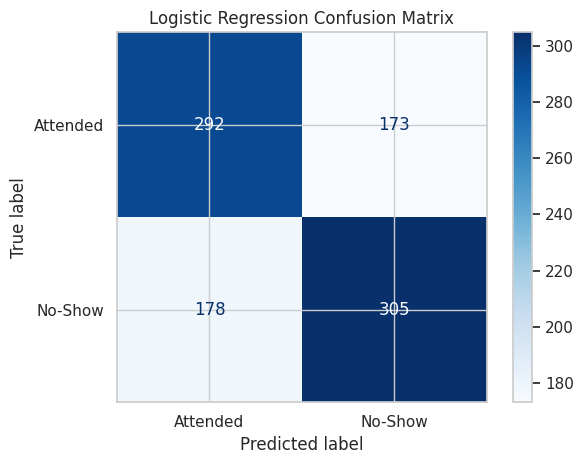

In [46]:
cm = confusion_matrix(
    y_test,
    predictions
)

print("Confusion matrix:")
print(cm)

display_labels = [
    "Attended",
    "No-Show"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "confusion_matrix.png",
    dpi=300
)

plt.show()


24. ROC curve

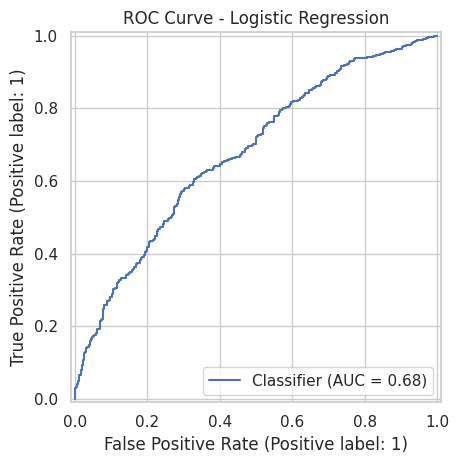

In [47]:
RocCurveDisplay.from_predictions(
    y_test,
    probabilities
)

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_curve.png",
    dpi=300
)

plt.show()


25. Examine model coefficients

Positive coefficients are associated with a higher predicted probability of a no-show. Negative coefficients are associated with a lower predicted probability.

In [48]:
fitted_preprocessor = (
    logistic_model
    .named_steps["preprocessor"]
)

classifier = (
    logistic_model
    .named_steps["classifier"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

coefficients = classifier.coef_[0]

coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

coefficient_df = coefficient_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(
    coefficient_df.head(20)
)


,feature,coefficient,absolute_coefficient
3,numeric__previous_no_shows,0.410030,0.410030
5,numeric__previous_no_show_rate,-0.292456,0.292456
6,numeric__has_previous_history,0.179450,0.179450
32,categorical__appointment_day_Wednesday,0.166765,0.166765
26,categorical__appointment_day_Friday,-0.165737,0.165737
15,categorical__gender_Prefer not to say,-0.132284,0.132284
29,categorical__appointment_day_Sunday,0.115936,0.115936
31,categorical__appointment_day_Tuesday,-0.097298,0.097298
44,categorical__distance_band_far,-0.091506,0.091506
47,categorical__distance_band_very_far,0.088334,0.088334


26. Plot important coefficients


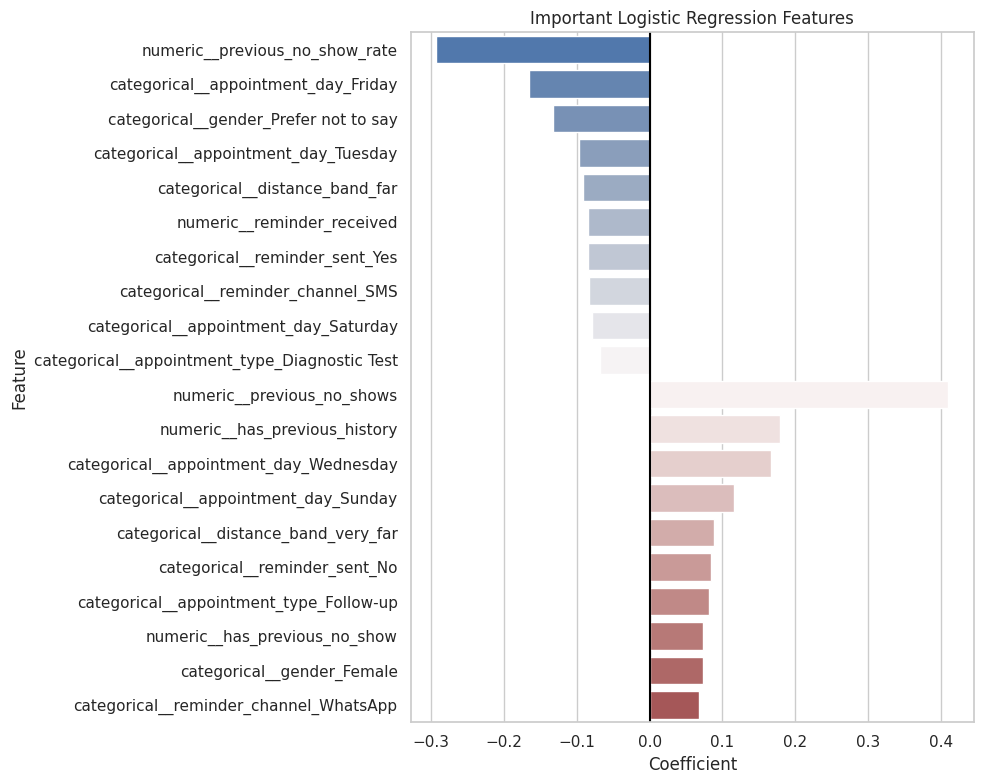

In [49]:
top_positive = (
    coefficient_df
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(10)
)

top_negative = (
    coefficient_df
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(10)
)

coefficient_plot_df = pd.concat([
    top_negative,
    top_positive
])

plt.figure(figsize=(10, 8))

sns.barplot(
    data=coefficient_plot_df,
    x="coefficient",
    y="feature",
    palette="vlag"
)

plt.axvline(
    0,
    color="black"
)

plt.title(
    "Important Logistic Regression Features"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_coefficients.png",
    dpi=300
)

plt.show()


27. Save the model and evaluation results


In [50]:
# Save trained model
model_path = (
    MODELS_DIR /
    "healthconnect_logistic_regression_model.joblib"
)

joblib.dump(
    logistic_model,
    model_path
)

# Save metrics
metrics_path = (
    REPORTS_DIR /
    "baseline_model_metrics.csv"
)

metrics.to_csv(
    metrics_path,
    index=False
)

# Save coefficients
coefficients_path = (
    REPORTS_DIR /
    "model_coefficients.csv"
)

coefficient_df.to_csv(
    coefficients_path,
    index=False
)

print("Model saved to:", model_path)
print("Metrics saved to:", metrics_path)
print("Coefficients saved to:", coefficients_path)


Model saved to: /content/models/healthconnect_logistic_regression_model.joblib
Metrics saved to: /content/reports/baseline_model_metrics.csv
Coefficients saved to: /content/reports/model_coefficients.csv


28. Save test-set predictions


In [51]:
prediction_results = model_df.loc[
    test_indices,
    [
        "appointment_id",
        "patient_id",
        "appointment_date",
        "appointment_outcome",
        "target_no_show"
    ]
].copy()

prediction_results["predicted_no_show"] = predictions
prediction_results["no_show_probability"] = probabilities

prediction_results["predicted_label"] = np.where(
    prediction_results["predicted_no_show"] == 1,
    "No-Show",
    "Attended"
)

prediction_path = (
    REPORTS_DIR /
    "test_set_predictions.csv"
)

prediction_results.to_csv(
    prediction_path,
    index=False
)

display(prediction_results.head())

print(
    "Predictions saved to:",
    prediction_path
)


,appointment_id,patient_id,appointment_date,appointment_outcome,target_no_show,predicted_no_show,no_show_probability,predicted_label
3789,HC-00716,P-0045,2026-03-13,Attended,0,1,0.573342,No-Show
3790,HC-01578,P-1709,2026-03-13,Attended,0,0,0.195236,Attended
3791,HC-03571,P-1269,2026-03-13,No-Show,1,1,0.613493,No-Show
3792,HC-04271,P-1308,2026-03-13,No-Show,1,1,0.724010,No-Show
3793,HC-03481,P-1596,2026-03-13,Attended,0,0,0.421542,Attended


Predictions saved to: /content/reports/test_set_predictions.csv


Week 5 summary

In [52]:
summary = {
    "project": "HealthConnect",
    "week": 5,
    "track": "Data Science",
    "problem": (
        "Predict whether an appointment will be attended "
        "or missed"
    ),
    "target": {
        "0": "Attended",
        "1": "No-Show"
    },
    "cancelled_records": (
        "Excluded from the primary binary classification model"
    ),
    "model": "Logistic Regression",
    "data_split": (
        "Chronological 80% training and 20% testing split"
    ),
    "leakage_control": [
        "waiting_time_minutes excluded",
        "appointment_outcome excluded",
        "identifiers excluded",
        "raw date columns excluded"
    ],
    "metrics": {
        row["Metric"]: float(row["Value"])
        for _, row in metrics.iterrows()
    },
    "recommendations_for_week_6": [
        "Compare Logistic Regression with tree-based models",
        "Test different probability thresholds",
        "Investigate patient-level group splitting",
        "Perform cross-validation",
        "Review fairness across demographic groups",
        "Consider operational cost of false negatives",
        "Improve missing-data and inconsistent-record handling"
    ]
}

summary_path = (
    REPORTS_DIR /
    "week_5_project_summary.json"
)

with open(summary_path, "w") as file:
    json.dump(
        summary,
        file,
        indent=4
    )

print(
    "Week 5 summary saved to:",
    summary_path
)


Week 5 summary saved to: /content/reports/week_5_project_summary.json


Output

In [53]:
print("=" * 60)
print("HEALTHCONNECT WEEK 5 COMPLETE")
print("=" * 60)

print("Original records:", len(df))
print("Records used for modelling:", len(model_df))
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nModel performance:")
display(metrics)

print("\nOutput folders:")
print("Processed data:", PROCESSED_DIR)
print("Figures:", FIGURES_DIR)
print("Models:", MODELS_DIR)
print("Reports:", REPORTS_DIR)


HEALTHCONNECT WEEK 5 COMPLETE
Original records: 5000
Records used for modelling: 4737
Training records: 3789
Testing records: 948

Model performance:


,Metric,Value
0,Accuracy,0.6297
1,Precision,0.6381
2,Recall,0.6315
3,F1-score,0.6348
4,ROC-AUC,0.6763



Output folders:
Processed data: /content/data/processed
Figures: /content/figures
Models: /content/models
Reports: /content/reports
